In [ ]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure

In [2]:
data_dir = "data"
output_dir = os.path.join(data_dir, "preprocessed")
os.makedirs(output_dir, exist_ok=True)

In [3]:
sample_subject = "sub-BrainAge000019"
sample_path = os.path.join(data_dir, sample_subject, "anat", f"{sample_subject}_T1w.nii.gz")

In [4]:
sample_path

'data/sub-BrainAge000019/anat/sub-BrainAge000019_T1w.nii.gz'

## Show image

In [5]:
brain_vol = nib.load(sample_path)
print(brain_vol)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (130, 130, 130)
affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 130 130 130   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0

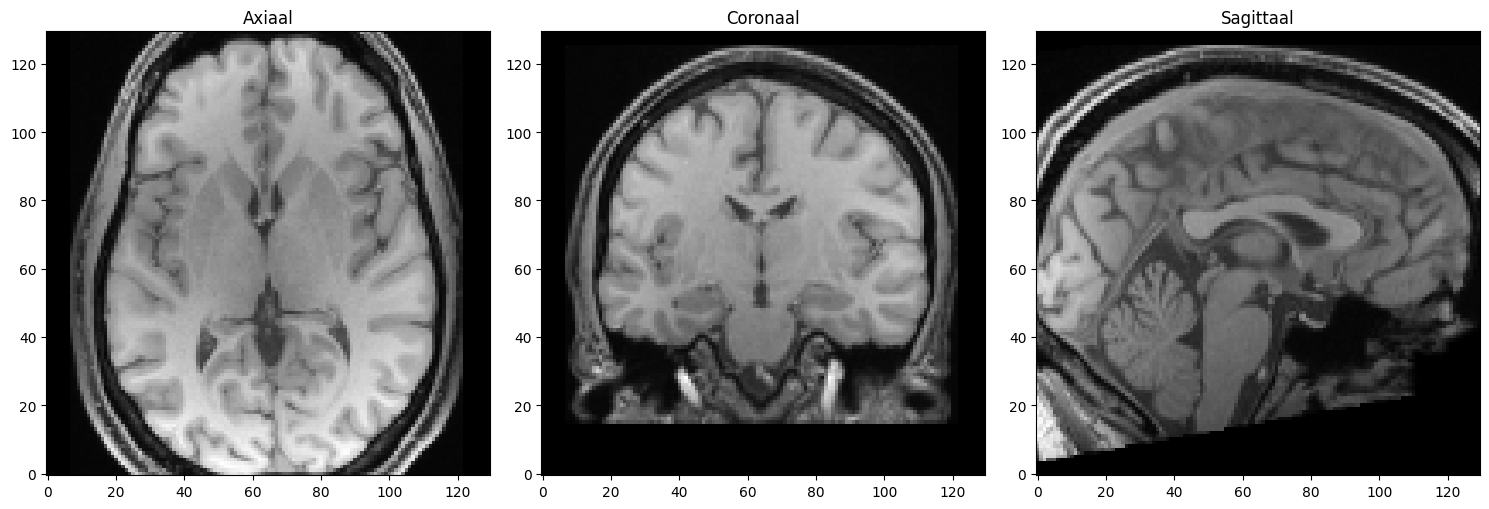

In [6]:
brain_vol_data = brain_vol.get_fdata()

axiaal_slice = brain_vol_data[:, :, int(brain_vol_data.shape[2] / 2)]
coronaal_slice = brain_vol_data[:, int(brain_vol_data.shape[1] / 2), :]
sagittaal_slice = brain_vol_data[int(brain_vol_data.shape[0] / 2), :, :]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(axiaal_slice.T, cmap='gray', origin='lower')
axes[0].set_title('Axiaal')
axes[1].imshow(coronaal_slice.T, cmap='gray', origin='lower')
axes[1].set_title('Coronaal')
axes[2].imshow(sagittaal_slice.T, cmap='gray', origin='lower')
axes[2].set_title('Sagittaal')

plt.tight_layout()
plt.show()

## Bias Field Correction

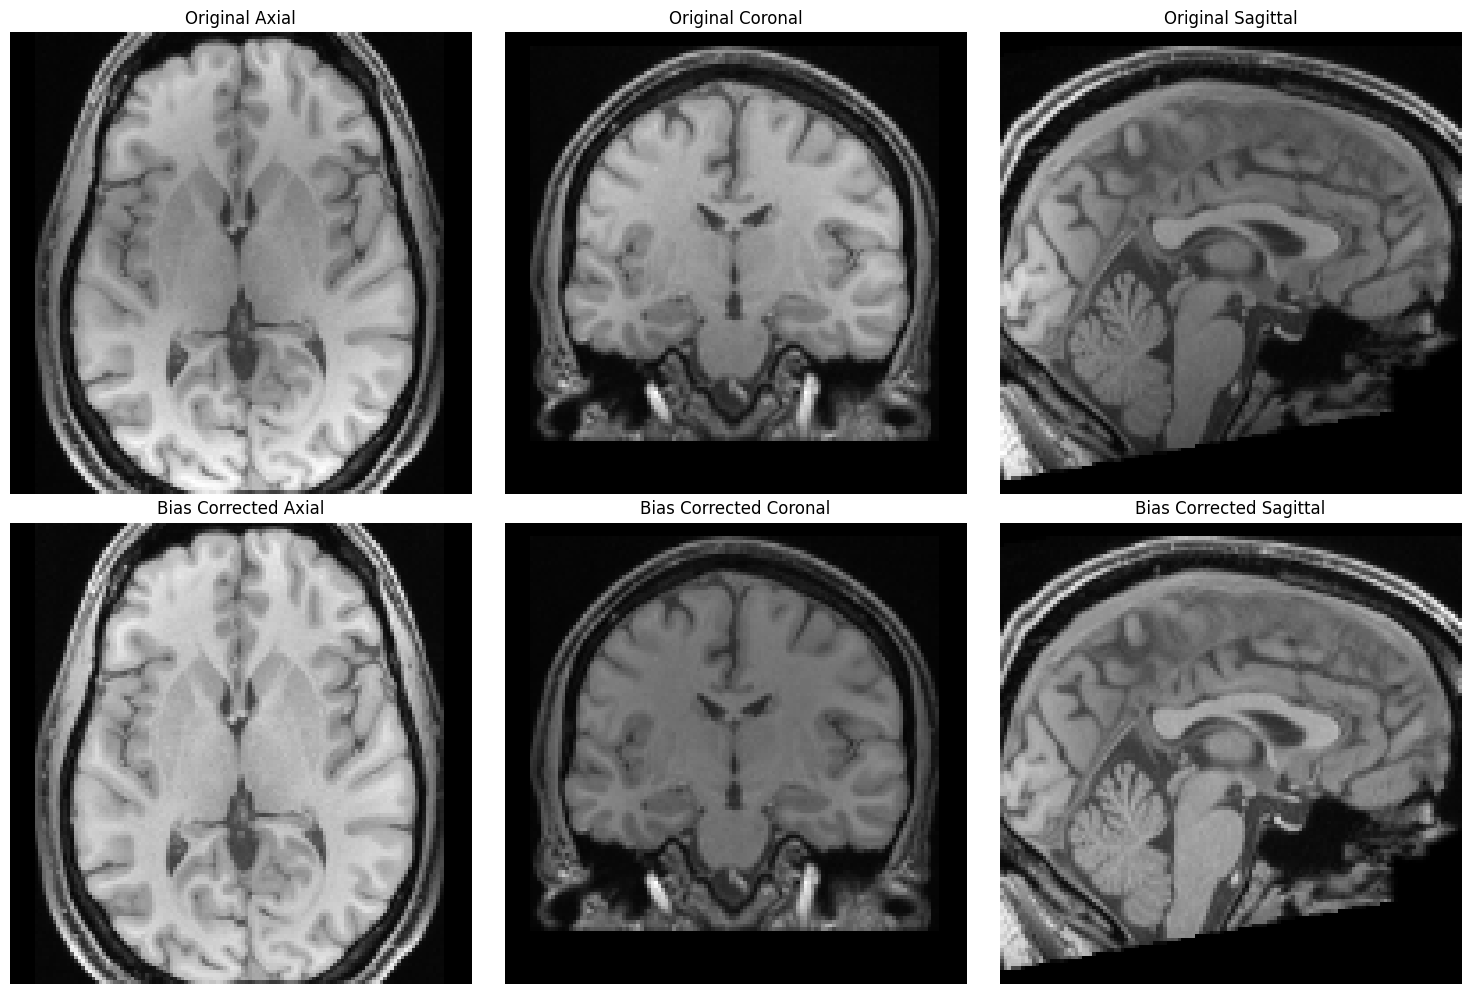

In [ ]:
img_orig = nib.load("/home/ntdung/Medical/data/sub-BrainAge000019/anat/sub-BrainAge000019_T1w.nii.gz").get_fdata()
img_corr = nib.load("/home/ntdung/Medical/data/sub-BrainAge000019/anat/sub-BrainAge000019_T1w_restore.nii.gz").get_fdata()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2x3

# Axial view (Z)
axes[0, 0].imshow(img_orig[:, :, img_orig.shape[2]//2].T, cmap="gray", origin="lower")
axes[0, 0].set_title("Original Axial")
axes[1, 0].imshow(img_corr[:, :, img_corr.shape[2]//2].T, cmap="gray", origin="lower")
axes[1, 0].set_title("Bias Corrected Axial")

# Coronal view (Y)
axes[0, 1].imshow(img_orig[:, img_orig.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[0, 1].set_title("Original Coronal")
axes[1, 1].imshow(img_corr[:, img_corr.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[1, 1].set_title("Bias Corrected Coronal")

# Sagittal view (X)
axes[0, 2].imshow(img_orig[img_orig.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[0, 2].set_title("Original Sagittal")
axes[1, 2].imshow(img_corr[img_corr.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[1, 2].set_title("Bias Corrected Sagittal")

for ax in axes.flatten(): ax.axis('off')
plt.tight_layout()
plt.show()

## Skull Stripping

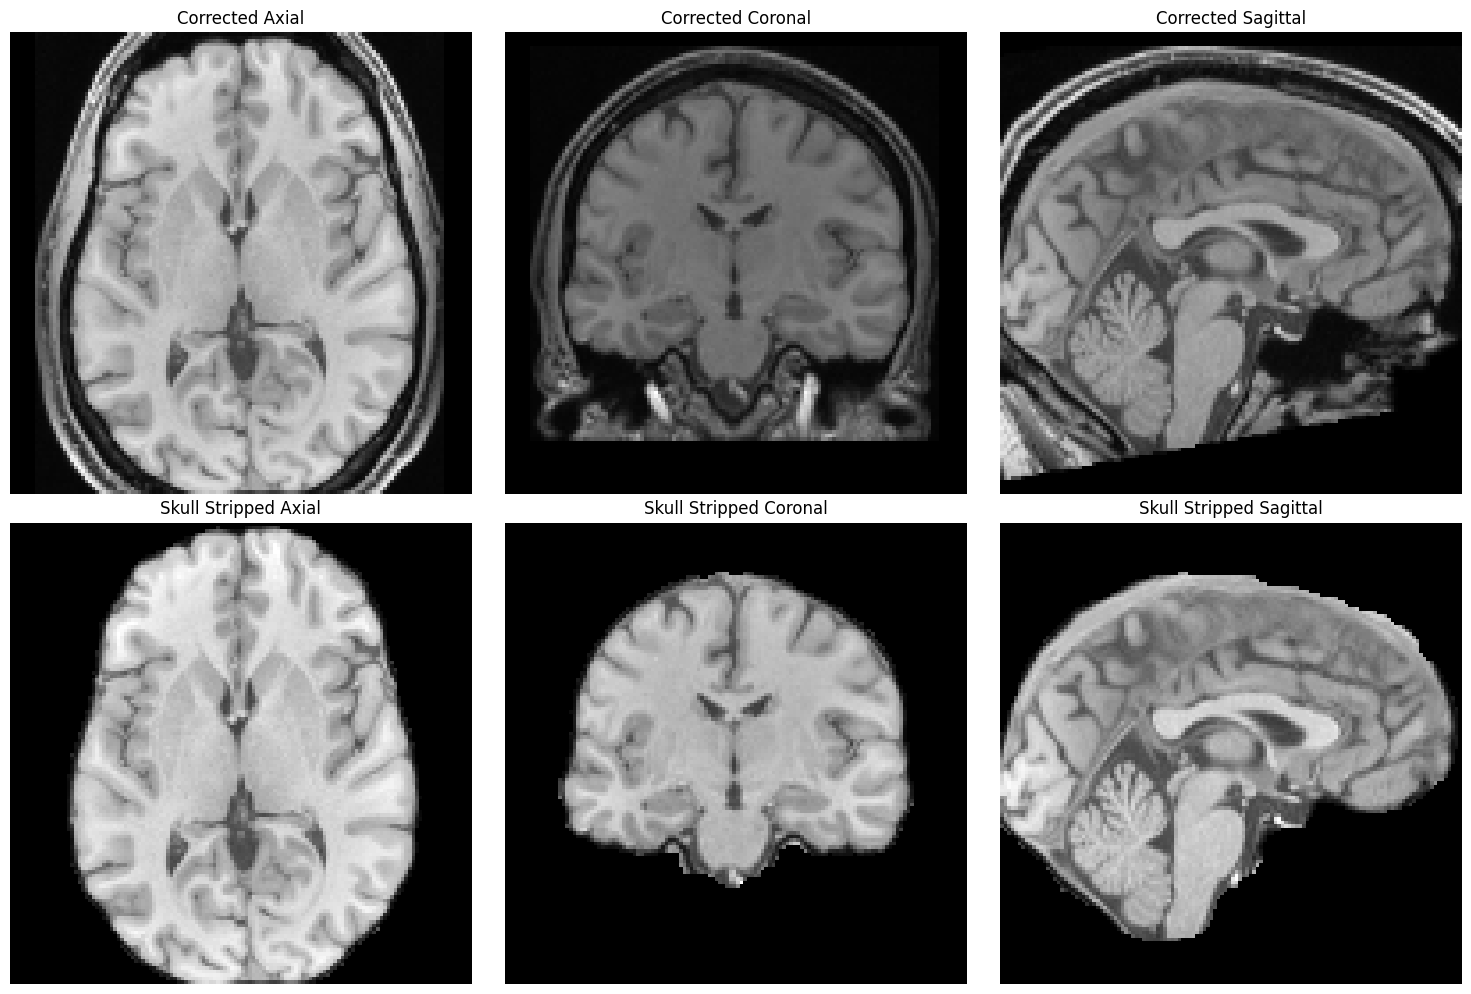

In [ ]:
img_corr = nib.load("/home/ntdung/Medical/data/sub-BrainAge000019/anat/sub-BrainAge000019_T1w_restore.nii.gz").get_fdata()
img_brain = nib.load("/home/ntdung/Medical/data/sub-BrainAge000019/anat/sub-BrainAge000019_T1w_brain.nii.gz").get_fdata()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2x3 grid for displaying

# Axial view (Z)
axes[0, 0].imshow(img_corr[:, :, img_corr.shape[2]//2].T, cmap="gray", origin="lower")
axes[0, 0].set_title("Corrected Axial")
axes[1, 0].imshow(img_brain[:, :, img_brain.shape[2]//2].T, cmap="gray", origin="lower")
axes[1, 0].set_title("Skull Stripped Axial")

# Coronal view (Y)
axes[0, 1].imshow(img_corr[:, img_corr.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[0, 1].set_title("Corrected Coronal")
axes[1, 1].imshow(img_brain[:, img_brain.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[1, 1].set_title("Skull Stripped Coronal")

# Sagittal view (X
axes[0, 2].imshow(img_corr[img_corr.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[0, 2].set_title("Corrected Sagittal")
axes[1, 2].imshow(img_brain[img_brain.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[1, 2].set_title("Skull Stripped Sagittal")

for ax in axes.flatten(): ax.axis('off')
plt.tight_layout()
plt.show()

## Intensity Normalization

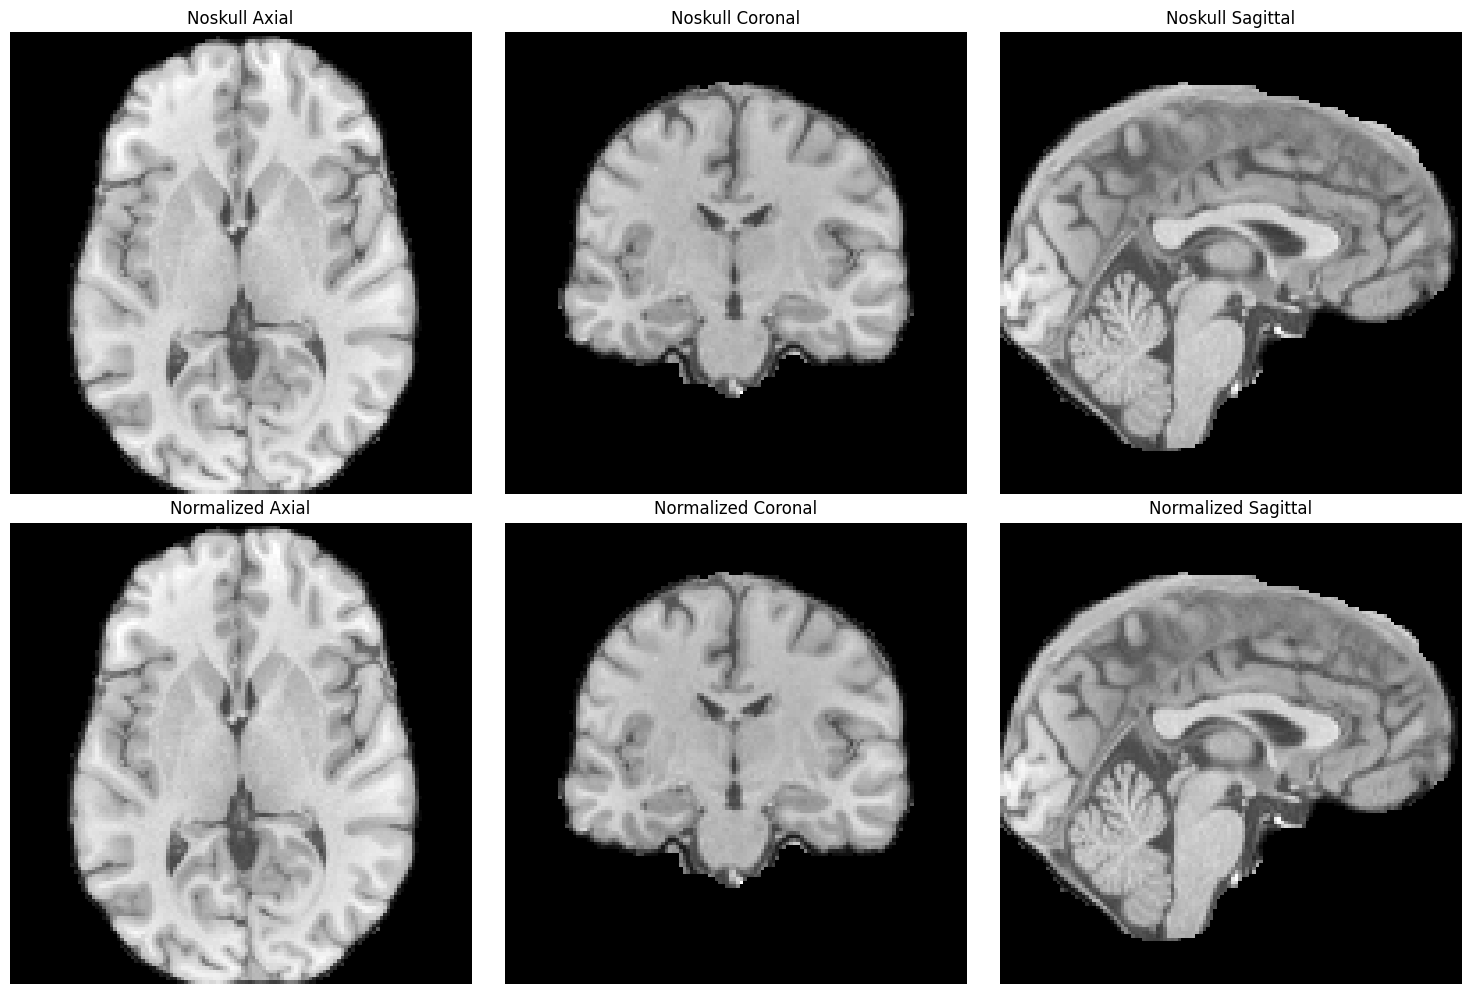

In [ ]:
img_brain = nib.load("/home/ntdung/Medical/data/sub-BrainAge000019/anat/sub-BrainAge000019_T1w_brain.nii.gz").get_fdata()

# Z-score normalization
img_zscore = (img_brain - np.mean(img_brain)) / np.std(img_brain)

z_img = nib.Nifti1Image(img_zscore, affine=np.eye(4))  # affine = np.eye(4) là mặc định cho ảnh chuẩn
nib.save(z_img, "/home/ntdung/Medical/data/sub-BrainAge000019/anat/sub-BrainAge000019_T1w_zscore.nii.gz")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 

# Axial view (Z)
axes[0, 0].imshow(img_brain[:, :, img_brain.shape[2]//2].T, cmap="gray", origin="lower")
axes[0, 0].set_title("Noskull Axial")
axes[1, 0].imshow(img_zscore[:, :, img_zscore.shape[2]//2].T, cmap="gray", origin="lower")
axes[1, 0].set_title("Normalized Axial")

# Coronal view (Y)
axes[0, 1].imshow(img_brain[:, img_brain.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[0, 1].set_title("Noskull Coronal")
axes[1, 1].imshow(img_zscore[:, img_zscore.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[1, 1].set_title("Normalized Coronal")

# Sagittal view (X)
axes[0, 2].imshow(img_brain[img_brain.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[0, 2].set_title("Noskull Sagittal")
axes[1, 2].imshow(img_zscore[img_zscore.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[1, 2].set_title("Normalized Sagittal")

for ax in axes.flatten(): ax.axis('off')
plt.tight_layout()
plt.show()

## Histogram Equalization

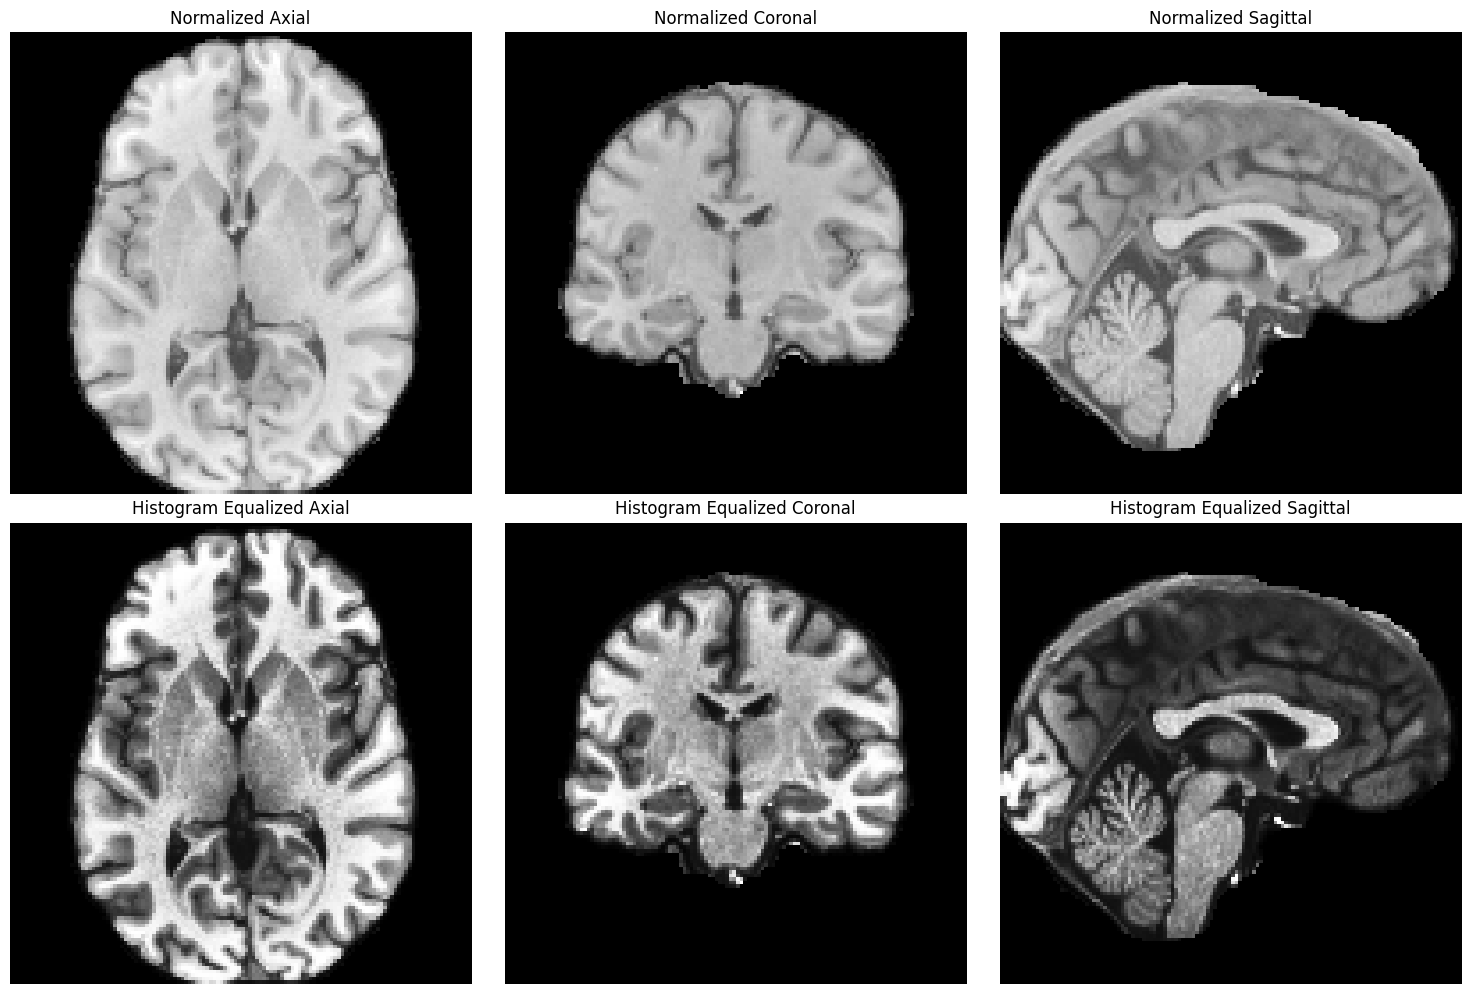

In [ ]:
img_zscore = nib.load("/home/ntdung/Medical/data/sub-BrainAge000019/anat/sub-BrainAge000019_T1w_zscore.nii.gz").get_fdata()

# Histogram equalization
img_equalized = exposure.equalize_hist(img_zscore)

hequal_img = nib.Nifti1Image(img_equalized, affine=np.eye(4))  # affine = np.eye(4) là mặc định cho ảnh chuẩn
nib.save(hequal_img, "/home/ntdung/Medical/data/sub-BrainAge000019/anat/sub-BrainAge000019_T1w_hequal.nii.gz")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2x3

# Axial view (Z)
axes[0, 0].imshow(img_zscore[:, :, img_zscore.shape[2]//2].T, cmap="gray", origin="lower")
axes[0, 0].set_title("Normalized Axial")
axes[1, 0].imshow(img_equalized[:, :, img_equalized.shape[2]//2].T, cmap="gray", origin="lower")
axes[1, 0].set_title("Histogram Equalized Axial")

# Coronal view (Y)
axes[0, 1].imshow(img_zscore[:, img_zscore.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[0, 1].set_title("Normalized Coronal")
axes[1, 1].imshow(img_equalized[:, img_equalized.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[1, 1].set_title("Histogram Equalized Coronal")

# Sagittal view (X)
axes[0, 2].imshow(img_zscore[img_zscore.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[0, 2].set_title("Normalized Sagittal")
axes[1, 2].imshow(img_equalized[img_equalized.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[1, 2].set_title("Histogram Equalized Sagittal")

for ax in axes.flatten(): ax.axis('off')
plt.tight_layout()
plt.show()

# Preprocessing pipepline

### Any sample in dataset

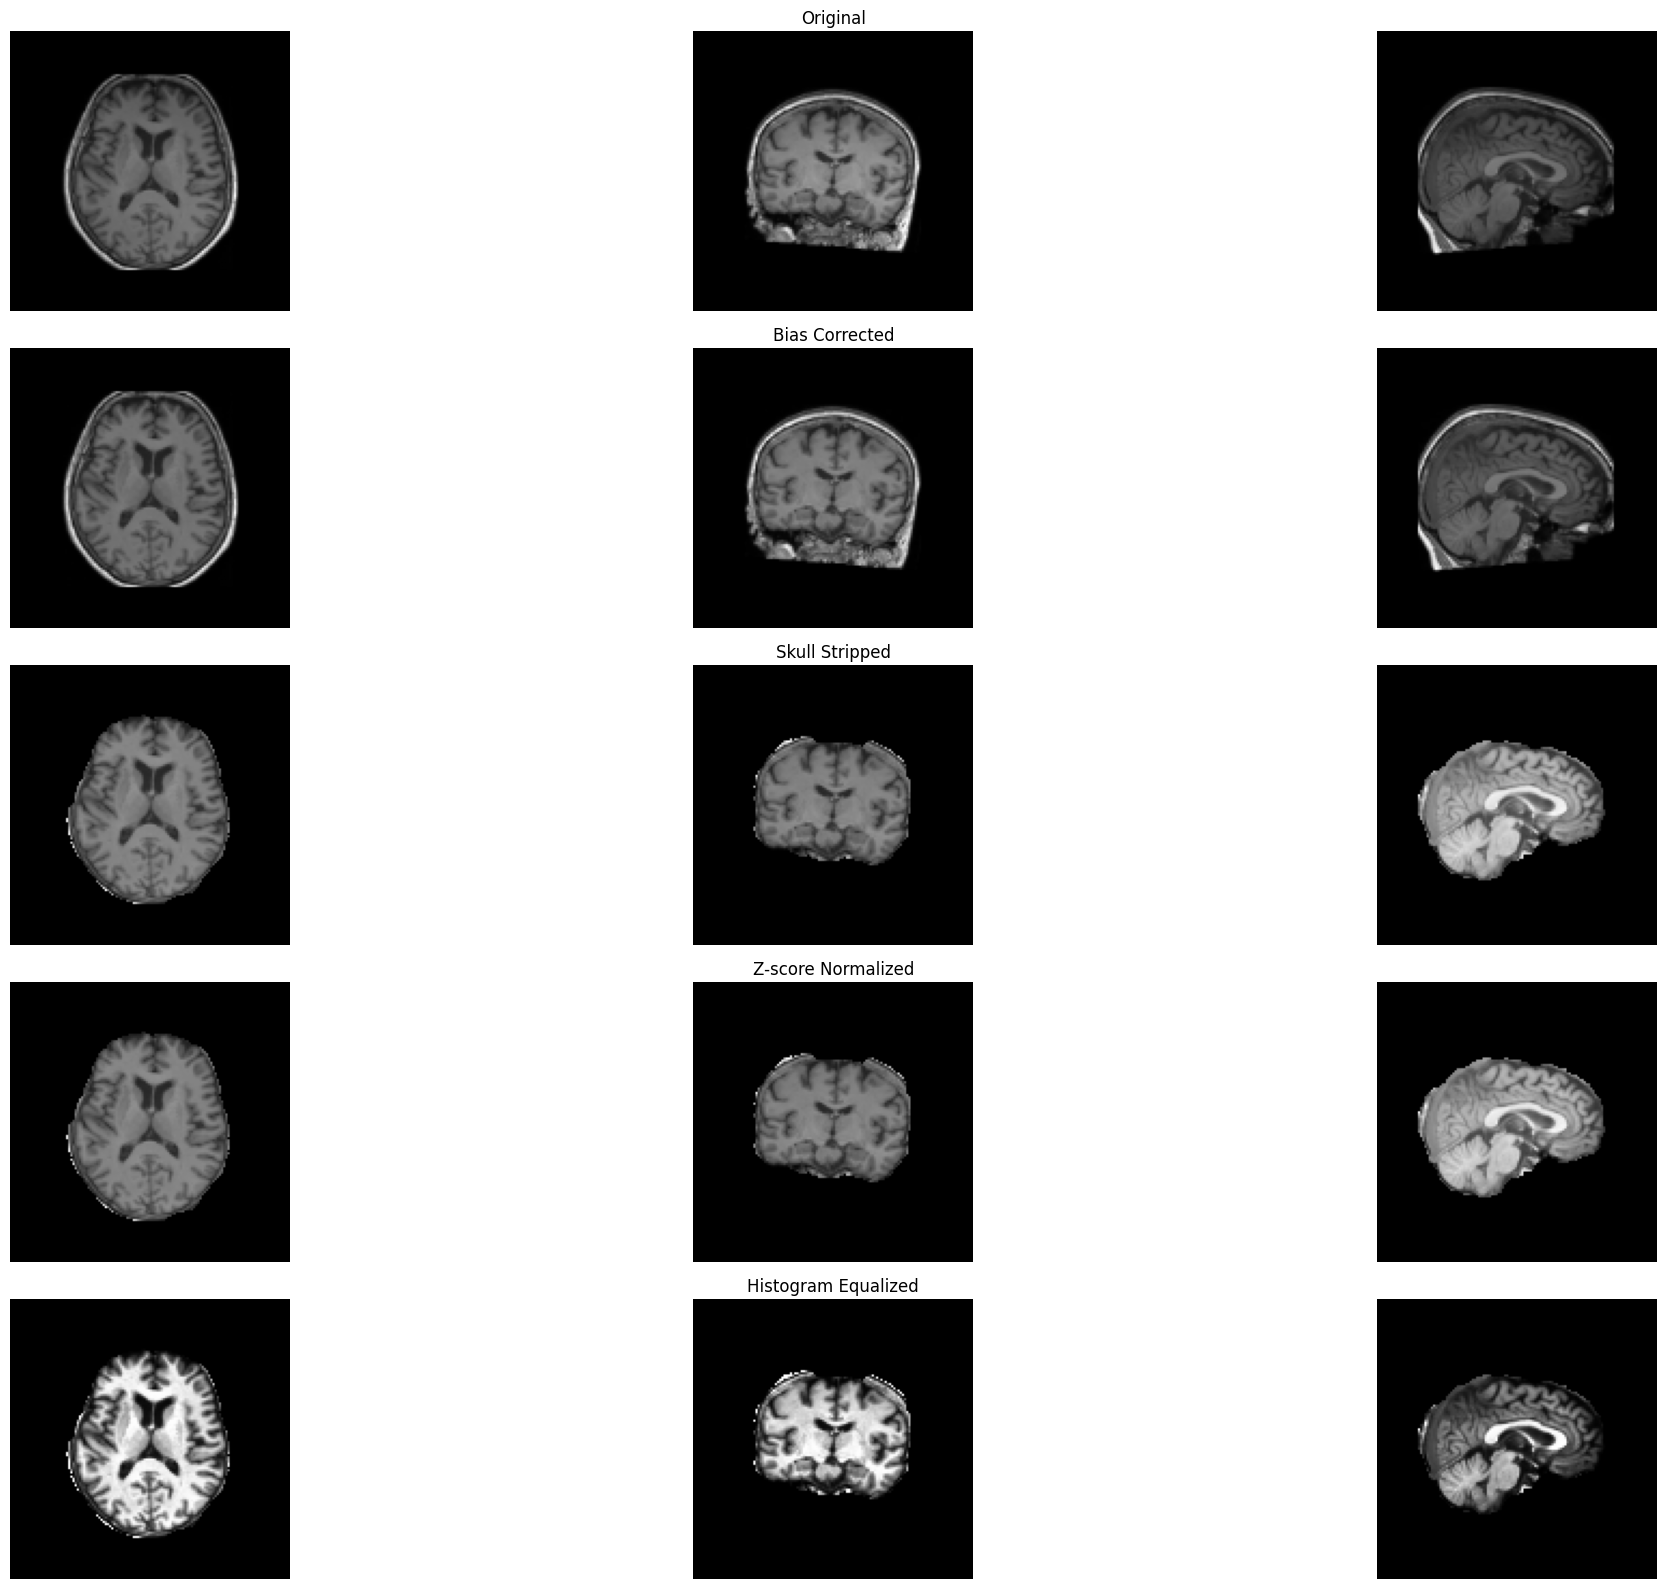

In [ ]:
import os
import subprocess

subject_id = "sub-BrainAge023213"

base_path = "/home/ntdung/Medical/data"
anat_path = os.path.join(base_path, subject_id, "anat")
input_nii = os.path.join(anat_path, f"{subject_id}_T1w.nii.gz")

# File tạm
restore_nii = os.path.join(anat_path, "temp_restore.nii.gz")
brain_nii = os.path.join(anat_path, "temp_brain.nii.gz")

# Step 1: Bias Field Correction
subprocess.run(f"fast -B -o {anat_path}/temp {input_nii}", shell=True, check=True)

# Step 2: Skull Stripping
subprocess.run(f"bet {restore_nii} {brain_nii} -f 0.3 -g 0 -m", shell=True, check=True)

# Step 3: Z-Score Normalization
brain_img = nib.load(brain_nii)
brain_data = brain_img.get_fdata()
brain_mask = brain_data > 0
zscore = (brain_data - brain_data[brain_mask].mean()) / brain_data[brain_mask].std()

# Step 4: Histogram Equalization
hequal = exposure.equalize_hist(zscore)

# Visualization
def show_slices(data_list, titles):
    fig, axes = plt.subplots(len(data_list), 3, figsize=(24, 16))
    for i, vol in enumerate(data_list):
        ax = vol[:, :, vol.shape[2] // 2].T
        co = vol[:, vol.shape[1] // 2, :].T
        sa = vol[vol.shape[0] // 2, :, :].T
        for j, slc in enumerate([ax, co, sa]):
            axes[i, j].imshow(slc, cmap="gray", origin="lower")
            axes[i, j].axis("off")
            if j == 1:
                axes[i, j].set_title(titles[i], fontsize=12)
    plt.tight_layout()
    plt.show()

# Load & Show
orig = nib.load(input_nii).get_fdata()
restored = nib.load(restore_nii).get_fdata()
brain = nib.load(brain_nii).get_fdata()

show_slices([orig, restored, brain, zscore, hequal],
            ["Original", "Bias Corrected", "Skull Stripped", "Z-score Normalized", "Histogram Equalized"])

# Cleanup
for f in ["temp_restore.nii.gz", "temp_restore_pve_0.nii.gz", "temp_restore_pve_1.nii.gz",
          "temp_restore_pve_2.nii.gz", "temp_restore_pveseg.nii.gz", "temp_restore_mixeltype.nii.gz",
          "temp_restore_seg.nii.gz", "temp_restore_brain_mask.nii.gz", "temp_restore_brain.nii.gz", 
          "temp_brain.nii.gz", "temp_restore_bias.nii.gz"]:
    f_path = os.path.join(anat_path, f)
    if os.path.exists(f_path):
        os.remove(f_path)


### Multiple samples

#### Single process

In [1]:
import os
import shutil
import subprocess
from glob import glob
import nibabel as nib
import numpy as np
from skimage import exposure

source_root = "/home/ntdung/Medical/data"
dest_root = "/home/ntdung/Medical/data_processed"
anat_folder = "anat"

os.makedirs(dest_root, exist_ok=True)
shutil.copy2(os.path.join(source_root, "participants.xlsx"),
             os.path.join(dest_root, "participants.xlsx"))

def zscore_normalize(volume):
    brain_mask = volume > 0
    mean = np.mean(volume[brain_mask])
    std = np.std(volume[brain_mask])
    return (volume - mean) / std

subjects = sorted(glob(os.path.join(source_root, "sub-*")))[10:20]
for subj_path in subjects:
    subj_id = os.path.basename(subj_path)
    anat_path = os.path.join(subj_path, anat_folder)
    input_nii = os.path.join(anat_path, f"{subj_id}_T1w.nii.gz")

    dest_anat = os.path.join(dest_root, subj_id, anat_folder)
    os.makedirs(dest_anat, exist_ok=True)

    temp_restore = os.path.join(dest_anat, "temp_restore.nii.gz")
    temp_brain = os.path.join(dest_anat, "temp_brain.nii.gz")

    # Bias correction
    subprocess.run(f"fast -B -o {dest_anat}/temp {input_nii}", shell=True, check=True)

    # Skull stripping
    subprocess.run(f"bet {temp_restore} {temp_brain} -f 0.3 -g 0 -m", shell=True, check=True)

    # Z-score + Histogram Equalization
    img = nib.load(temp_brain)
    data = img.get_fdata()
    zscore = zscore_normalize(data)
    hequal = exposure.equalize_hist(zscore)

    # Save
    final_img = nib.Nifti1Image(hequal, img.affine, img.header)
    nib.save(final_img, os.path.join(dest_anat, f"{subj_id}_T1w_processed.nii.gz"))

    # Cleanup temporary files
    for f in glob(os.path.join(dest_anat, "temp*")):
        os.remove(f)

    print(f"✅ Processed {subj_id}")

print("🎉 Done. Final processed images saved to:", dest_root)

✅ Processed sub-BrainAge000029
✅ Processed sub-BrainAge000030
✅ Processed sub-BrainAge000032
✅ Processed sub-BrainAge000033
✅ Processed sub-BrainAge000034
✅ Processed sub-BrainAge000035
✅ Processed sub-BrainAge000036
✅ Processed sub-BrainAge000037
✅ Processed sub-BrainAge000044
✅ Processed sub-BrainAge000045
🎉 Done. Final processed images saved to: /home/ntdung/Medical/data_processed


#### Multiple parallel processes

In [2]:
import os
import shutil
import subprocess
from glob import glob
import nibabel as nib
import numpy as np
from skimage import exposure
from multiprocessing import Pool

source_root = "/home/ntdung/Medical/data"
dest_root = "/home/ntdung/Medical/data_processed"
anat_folder = "anat"

os.makedirs(dest_root, exist_ok=True)
shutil.copy2(os.path.join(source_root, "participants.xlsx"),
             os.path.join(dest_root, "participants.xlsx"))

def zscore_normalize(volume):
    brain_mask = volume > 0
    mean = np.mean(volume[brain_mask])
    std = np.std(volume[brain_mask])
    return (volume - mean) / std

def process_subject(subj_path):
    subj_id = os.path.basename(subj_path)
    anat_path = os.path.join(subj_path, anat_folder)
    input_nii = os.path.join(anat_path, f"{subj_id}_T1w.nii.gz")

    dest_anat = os.path.join(dest_root, subj_id, anat_folder)
    os.makedirs(dest_anat, exist_ok=True)

    temp_restore = os.path.join(dest_anat, "temp_restore.nii.gz")
    temp_brain = os.path.join(dest_anat, "temp_brain.nii.gz")

    try:
        # Bias correction
        subprocess.run(f"fast -B -o {dest_anat}/temp {input_nii}", shell=True, check=True)

        # Skull stripping
        subprocess.run(f"bet {temp_restore} {temp_brain} -f 0.3 -g 0 -m", shell=True, check=True)

        # Z-score + Histogram Equalization
        img = nib.load(temp_brain)
        data = img.get_fdata()
        zscore = zscore_normalize(data)
        hequal = exposure.equalize_hist(zscore)

        final_img = nib.Nifti1Image(hequal, img.affine, img.header)
        nib.save(final_img, os.path.join(dest_anat, f"{subj_id}_T1w_processed.nii.gz"))

        # Cleanup temp files
        for f in glob(os.path.join(dest_anat, "temp*")):
            os.remove(f)

        print(f"✅ Processed {subj_id}")

    except Exception as e:
        print(f"❌ Failed: {subj_id} | Error: {e}")

In [8]:
subjects = sorted(glob(os.path.join(source_root, "sub-*")))[2700:3000]

num_processes = 5  # Customized by RAM and CPU
with Pool(processes=num_processes) as pool:
    pool.map(process_subject, subjects)

print("🎉 All done! Final processed images saved to:", dest_root)

✅ Processed sub-BrainAge020304
✅ Processed sub-BrainAge020320
✅ Processed sub-BrainAge020271
✅ Processed sub-BrainAge020288
✅ Processed sub-BrainAge020256
✅ Processed sub-BrainAge020305
✅ Processed sub-BrainAge020289
✅ Processed sub-BrainAge020321
✅ Processed sub-BrainAge020257
✅ Processed sub-BrainAge020272
✅ Processed sub-BrainAge020306
✅ Processed sub-BrainAge020322
✅ Processed sub-BrainAge020258
✅ Processed sub-BrainAge020290
✅ Processed sub-BrainAge020273
✅ Processed sub-BrainAge020307
✅ Processed sub-BrainAge020259
✅ Processed sub-BrainAge020323
✅ Processed sub-BrainAge020274
✅ Processed sub-BrainAge020291
✅ Processed sub-BrainAge020324
✅ Processed sub-BrainAge020308
✅ Processed sub-BrainAge020260
✅ Processed sub-BrainAge020275
✅ Processed sub-BrainAge020292
✅ Processed sub-BrainAge020325
✅ Processed sub-BrainAge020261
✅ Processed sub-BrainAge020309
✅ Processed sub-BrainAge020276
✅ Processed sub-BrainAge020293
✅ Processed sub-BrainAge020311
✅ Processed sub-BrainAge020262
✅ Proces

#### Output check

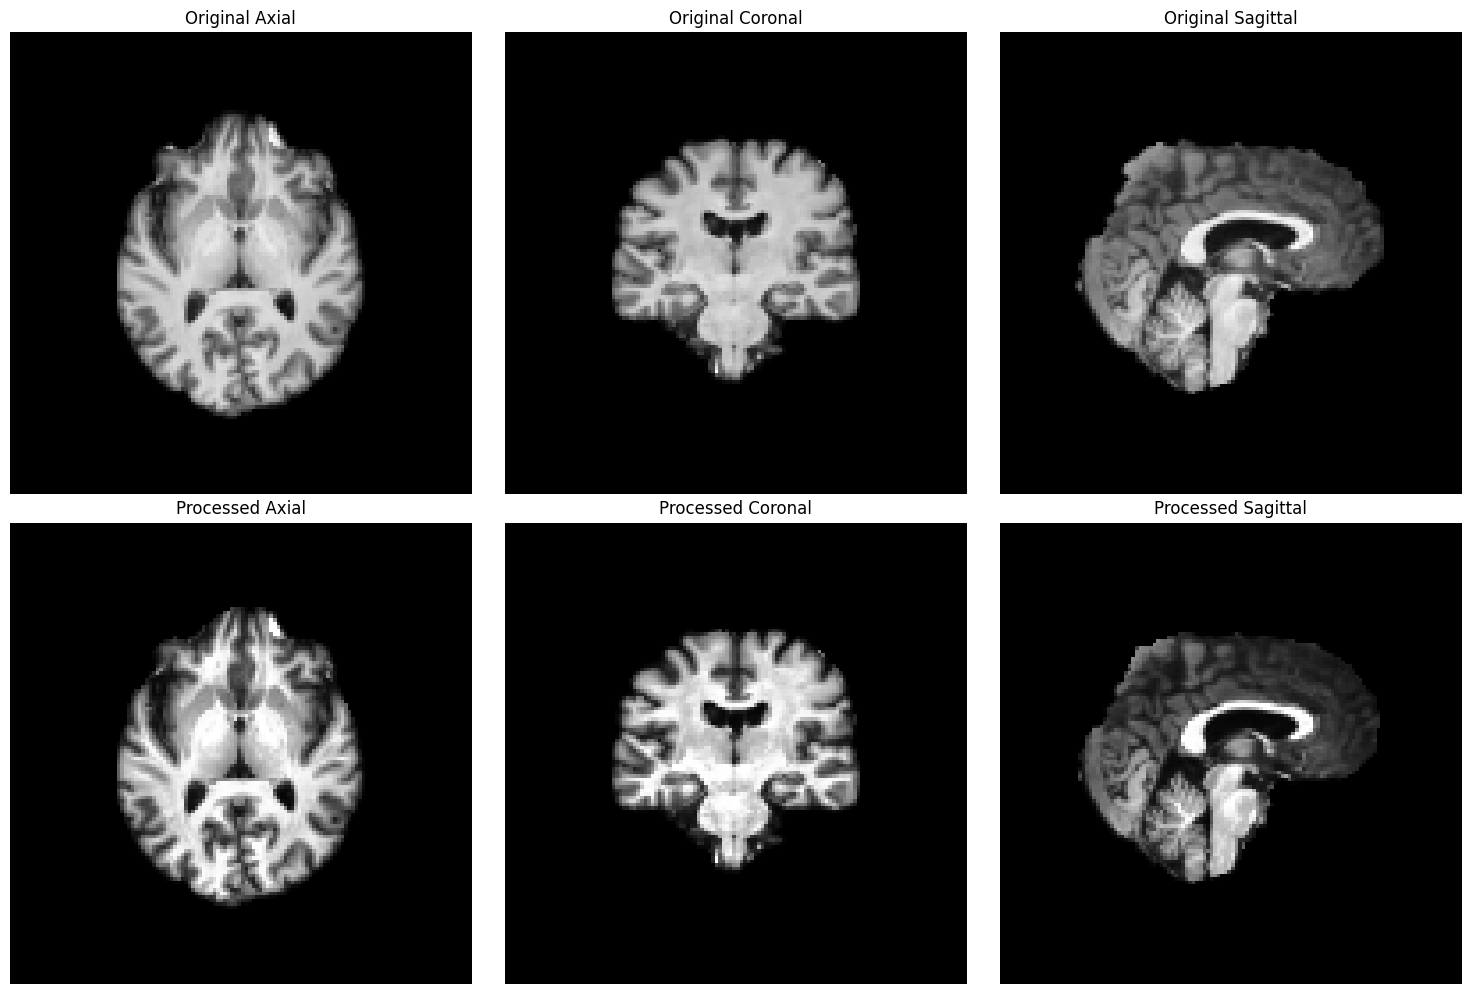

In [18]:
import nibabel as nib
import matplotlib.pyplot as plt

id = "sub-BrainAge014422"
img_orig = nib.load(f"/home/ntdung/Medical/data/{id}/anat/{id}_T1w.nii.gz").get_fdata()
img_proc = nib.load(f"/home/ntdung/Medical/data_processed/{id}/anat/{id}_T1w_processed.nii.gz").get_fdata()


fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img_orig[:, :, img_orig.shape[2]//2].T, cmap="gray", origin="lower")
axes[0, 0].set_title("Original Axial")
axes[1, 0].imshow(img_proc[:, :, img_proc.shape[2]//2].T, cmap="gray", origin="lower")
axes[1, 0].set_title("Processed Axial")

axes[0, 1].imshow(img_orig[:, img_orig.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[0, 1].set_title("Original Coronal")
axes[1, 1].imshow(img_proc[:, img_proc.shape[1]//2, :].T, cmap="gray", origin="lower")
axes[1, 1].set_title("Processed Coronal")

axes[0, 2].imshow(img_orig[img_orig.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[0, 2].set_title("Original Sagittal")
axes[1, 2].imshow(img_proc[img_proc.shape[0]//2, :, :].T, cmap="gray", origin="lower")
axes[1, 2].set_title("Processed Sagittal")

for ax in axes.flatten(): ax.axis('off')
plt.tight_layout()
plt.show()